Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

import sys
import os

sys.path.append(os.path.abspath(".."))

Load clr data

In [2]:
df = pd.read_csv("../data/processed/synthetic_geochemistry_clean.csv")
elements = [c for c in df.columns if c not in ["cluster_true"]]

from src.compositional_transforms import clr
df_clr = clr(df[elements])

Standardize data<br>

DBSCAN is scale-sensitive. Because CLR does not guarantee homogeneous variance between components, StandardScaler is necessary to prevent elements with higher variance from dominating the distance.

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df_clr)

Apply DBSCAN analysis

In [12]:
db = DBSCAN(eps=1.5, min_samples=10).fit(X)
labels = db.labels_

df_dbscan = df_clr.copy()
df_dbscan["cluster_dbscan"] = labels
df_dbscan["cluster_dbscan"] = df_dbscan["cluster_dbscan"].astype("category")

df_dbscan.head(10)

,Br,Cl,F,SO4,Ca,Mg,Sr,Cu,Co,Pb,Zn,Li,Na,K,Mn,Fe,Ba,cluster_dbscan
0,0.746251,0.315967,-0.725338,1.031902,0.322700,0.614582,0.798161,-1.001871,-1.241130,-0.897711,-1.715558,0.482986,0.800385,0.080730,0.569394,-0.131824,-0.049627,-1
1,0.729605,0.660838,-0.991739,0.888241,0.227267,0.054199,0.054580,-1.275910,-0.644361,-0.378698,-1.059244,0.209740,1.069177,0.445892,0.139806,-0.091344,-0.038048,-1
2,0.871193,1.011035,-0.627001,0.926490,0.385496,-0.278802,-0.442086,-1.435748,-1.106555,-0.182974,-1.053325,0.498767,1.727061,0.812838,0.019348,-0.379677,-0.746062,-1
3,1.090503,0.825440,-0.612017,1.420517,0.507270,0.079267,-0.975566,-0.768535,-1.127371,-0.709225,-0.263633,-0.129010,0.981496,-0.101476,-0.103580,0.487791,-0.601873,-1
4,0.449769,0.635069,-0.832540,0.938980,0.272746,0.041319,-1.058140,-1.632335,-0.287189,-0.956847,-0.733949,0.783759,1.278069,0.727864,0.498698,0.236396,-0.361669,-1
5,0.494237,0.734823,-0.349069,0.911110,0.312247,-0.084045,-0.904176,-0.455039,-0.375924,-0.594073,-1.446301,0.812440,0.850622,0.191283,0.174734,0.577595,-0.850466,-1
6,1.190138,1.169518,-1.173684,0.178524,-0.162743,0.576285,-0.007984,-1.501796,-1.461380,-0.983592,-0.747133,0.571255,0.824497,0.656082,0.705484,0.703689,-0.537159,-1
7,0.919244,0.475641,-1.261127,1.285397,-0.085471,0.785453,0.166632,-0.832373,-0.555837,-0.978169,-1.506652,0.556934,1.436865,-0.109775,-0.915043,0.545078,0.073202,-1
8,0.413773,0.920402,-1.432053,1.224305,-0.540000,0.254607,-0.889033,-1.229885,-0.573879,-1.139003,-0.465361,1.106038,0.696690,0.477334,0.073137,0.730444,0.372485,-1
9,0.613614,0.415713,-0.654597,1.778217,1.146336,0.883108,0.144109,-1.062135,-1.562715,-0.578045,-1.291860,0.196465,0.772026,-0.124441,-0.266437,0.161824,-0.571184,-1


Visualize it in PCA space

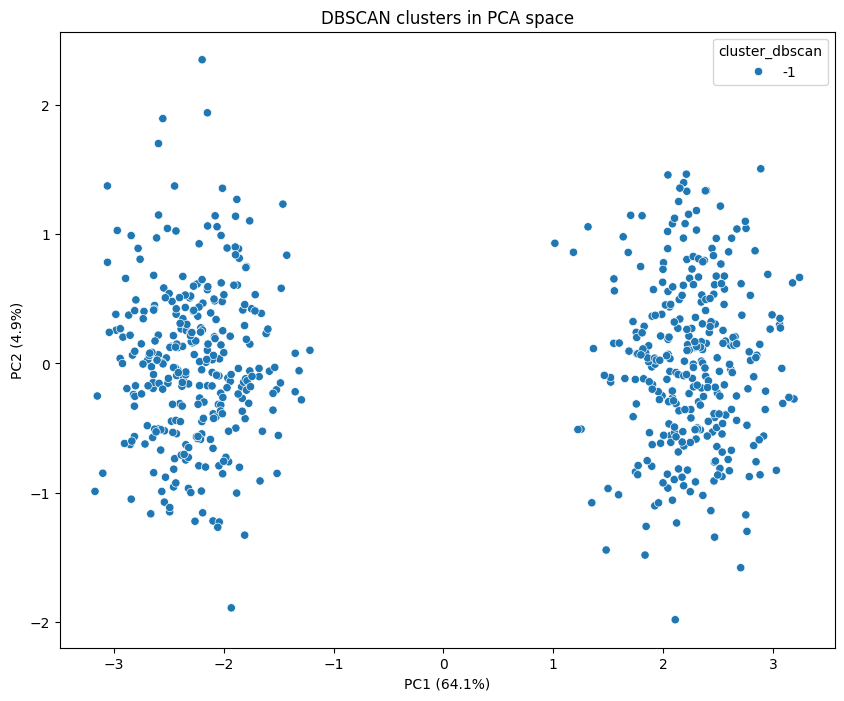

In [15]:
from src.pca_analysis import run_pca
pca, scores, _ = run_pca(df_dbscan.drop(columns=["cluster_dbscan"]))

plt.figure(figsize=(10,8))
sns.scatterplot(
    x=scores["PC1"], 
    y=scores["PC2"],
    hue=df_dbscan["cluster_dbscan"],
    palette="tab10"
)


plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.title("DBSCAN clusters in PCA space")
plt.show()